# Previsão de Séries Temporais
Este projeto cria e analisa dados sintéticos que simulam a temperatura operacional de um motor ao longo do tempo. O objetivo principal é utilizar o modelo preditivo Holt-Winters (Suavização Exponencial) para realizar a previsão de valores futuros com base nos padrões históricos de tendência e ciclos diários de aquecimento/resfriamento.

### Bibliotecas Utilizadas:
- NumPy: geração de dados e operações matemáticas
- Pandas: manipulação de dados em formato tabular
- Matplotlib: visualização gráfica
- Statsmodels: modelagem de séries temporais
- Scikit-learn: métricas de validação e acurácia do modelo

In [273]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

## Definição do período de análise
A variável `date_rng` representa o período de análise, sendo o parâmetro `start='2026-01-01'` o início, `periods=7*24*4` representando uma semana de dados, e `freq='15min'` a frequência de medições de 15 em 15 minutos.


In [274]:
date_rng = pd.date_range(start='2026-01-01', periods=7*24*4, freq='15min')

## Criando a tendência
`trend` representa a tendência da série temporal, ou seja, o comportamento dos dados ao longo do tempo, variando de `30` a `35`.

In [275]:
trend = np.linspace(30, 35, len(date_rng))

##Criando a sazonalidade
`seasonality` representa a variação periódica da série temporal, simulando um ciclo diário de comportamento, como o aquecimento e resfriamento de um motor ao longo do dia. O fator `2π/96` define um ciclo completo a cada 96 pontos, representando um comportamento diário nos dados.

In [276]:
seasonality = np.sin(np.arange(len(date_rng)) * 2 * np.pi / 96) * 2

##Criando o ruído
`noise` representa variações aleatórias nos dados, geradas por uma distribuição normal com média 0 e desvio padrão 0.5, simulando imperfeições comuns em medições reais.

In [277]:
np.random.seed(42)
noise = np.random.normal(0, 0.5, len(date_rng))

##Série final
A série final é representada pela soma entre a tendência, a sazonalidade e o ruído.

In [278]:
temperature = trend + seasonality + noise

##Criando o DataFrame
Criamos o DataFrame com uma coluna que representa a temperatura medida pelo sensor, sendo o índice definido pelo momento em que cada valor foi medido.

In [279]:
df = pd.DataFrame(
    {'Temperatura (°C)': temperature},
    index=date_rng
    )

## Divisão dos Dados (Treino e Teste)
Para avaliar a qualidade das nossas previsões de temperatura, precisamos dividir os dados de forma cronológica. Separamos as últimas 24 horas (96 medições) como dados de teste, e usaremos todo o histórico anterior para treinar o modelo.

In [280]:
test_size = 96

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

print(f"Tamanho do Treino: {len(train)}")
print(f"Tamanho do Teste: {len(test)}")

Tamanho do Treino: 576
Tamanho do Teste: 96


## Construção e Treinamento do Modelo
O modelo `ExponentialSmoothing` é utilizado para representar a série temporal, considerando os componentes físicos simulados. O parâmetro `trend='add'` indica uma tendência aditiva, e `seasonal='add'` uma sazonalidade aditiva. O `seasonal_periods=96` reflete o ciclo de 24 horas do motor.

O método `fit()` é responsável por treinar o modelo, ajustando seus parâmetros com base na base de treino.

In [281]:
model = ExponentialSmoothing(
    train['Temperatura (°C)'],
    trend='add',
    seasonal='add',
    seasonal_periods=96
)
fit = model.fit()

## Previsão dos Dados
O método `forecast` é utilizado para projetar os valores futuros. Passamos o tamanho exato da nossa base de teste (96 pontos) para podermos comparar a previsão com os dados reais.

In [282]:
forecast = fit.forecast(len(test))

## Modelo Ingênuo (Baseline)
Para comprovar a eficácia do modelo Holt-Winters, criamos uma *Baseline* usando a abordagem de Previsão Sazonal Ingênua (Seasonal Naive). Este modelo simples assume que a temperatura das próximas 24 horas será exatamente igual à das últimas 24 horas registradas no treino, ignorando a tendência de aquecimento contínuo.

In [283]:
baseline = train['Temperatura (°C)'].iloc[-96:].values
baseline_forecast = np.tile(baseline, int(np.ceil(len(test)/96)))[:len(test)]

## Validação e Comparação
A avaliação é feita comparando o Erro Médio Absoluto (MAE), a Raiz do Erro Quadrático Médio (RMSE) e o Erro Percentual Absoluto Médio (MAPE) de ambos os modelos. O objetivo é que o modelo preditivo apresente erros significativamente menores que a Baseline.

In [284]:
# Métricas do Modelo Holt-Winters
mae = mean_absolute_error(test['Temperatura (°C)'], forecast)
rmse = np.sqrt(mean_squared_error(test['Temperatura (°C)'], forecast))
mape = mean_absolute_percentage_error(test['Temperatura (°C)'], forecast)

# Métricas da Baseline
mae_baseline = mean_absolute_error(test['Temperatura (°C)'], baseline_forecast)
rmse_baseline = np.sqrt(mean_squared_error(test['Temperatura (°C)'], baseline_forecast))
mape_baseline = mean_absolute_percentage_error(test['Temperatura (°C)'], baseline_forecast)

# Comparação final
print("--- COMPARAÇÃO DE PERFORMANCE ---")
print(f"Modelo Holt-Winters -> MAE: {mae:.2f} °C | RMSE: {rmse:.2f} °C | MAPE: {mape*100:.2f}%")
print(f"Baseline (Ingênua)  -> MAE: {mae_baseline:.2f} °C | RMSE: {rmse_baseline:.2f} °C | MAPE: {mape_baseline*100:.2f}%")

--- COMPARAÇÃO DE PERFORMANCE ---
Modelo Holt-Winters -> MAE: 0.44 °C | RMSE: 0.57 °C | MAPE: 1.28%
Baseline (Ingênua)  -> MAE: 0.93 °C | RMSE: 1.10 °C | MAPE: 2.66%


## Visualização
O gráfico abaixo ilustra os dados reais (verde), a previsão do nosso modelo Holt-Winters (vermelho) e a previsão da Baseline (laranja). Fica evidente visualmente como o modelo principal consegue acompanhar a tendência de alta da temperatura, enquanto a Baseline permanece estagnada no padrão do dia anterior.

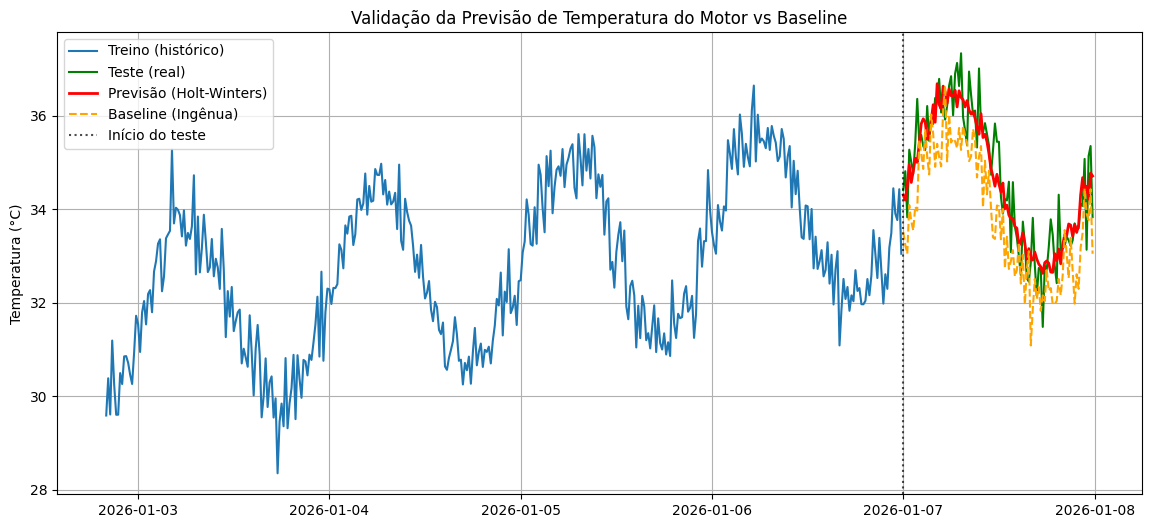

In [285]:
plt.figure(figsize=(14,6))

# Plotando os últimos dias de treino para contexto
plt.plot(train.index[-400:], train['Temperatura (°C)'].tail(400), label='Treino (histórico)')

# Plotando os dados reais de teste
plt.plot(test.index, test['Temperatura (°C)'], label='Teste (real)', color='green')

# Plotando a sua previsão vencedora (Holt-Winters)
plt.plot(test.index, forecast, label='Previsão (Holt-Winters)', color='red', linestyle='-', linewidth=2)

# Plotando a Baseline para comparação visual
plt.plot(test.index, baseline_forecast, label='Baseline (Ingênua)', color='orange', linestyle='--')

# Linha marcando o início do período de teste
plt.axvline(test.index[0], color='black', linestyle=':', alpha=0.7, label='Início do teste')

plt.title('Validação da Previsão de Temperatura do Motor vs Baseline')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()